In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons
import pandas as pd
from scipy.integrate import solve_ivp

DEVICE = torch.device("cpu")

G_AU = 4 * np.pi**2 

BODIES = {
    "Sun":     {"id": 10,  "mass": 1.0},
    "Earth":   {"id": 399, "mass": 3.003e-6},
    "Mars":    {"id": 499, "mass": 3.227e-7},
    "Jupiter": {"id": 599, "mass": 9.548e-4},
}
BODY_NAMES = list(BODIES.keys())
N_BODIES   = len(BODIES)
MASSES     = torch.tensor([BODIES[b]["mass"] for b in BODY_NAMES], dtype=torch.float32).to(DEVICE)

START, STOP, STEP = "2020-01-01", "2022-01-01", "10d"


In [7]:

def fetch_ephemeris():
    dfs = []
    for name, info in BODIES.items():
        obj = Horizons(id=info["id"], location="500@0",
                       epochs={"start": START, "stop": STOP, "step": STEP})
        vec = obj.vectors()
        df  = vec["datetime_jd", "x", "y", "z", "vx", "vy", "vz"].to_pandas()
        df.columns = ["jd", "x", "y", "z", "vx", "vy", "vz"]
        df["body"] = name
        dfs.append(df)
    return pd.concat(dfs).sort_values("jd")

raw = fetch_ephemeris()

jd_values = raw[raw["body"] == "Sun"]["jd"].values
t_days    = jd_values - jd_values[0]
t_years   = t_days / 365.25
T         = len(t_years)

states = np.zeros((T, N_BODIES, 6))
for i, name in enumerate(BODY_NAMES):
    sub = raw[raw["body"] == name].sort_values("jd")
    states[:, i, 0] = sub["x"].values
    states[:, i, 1] = sub["y"].values
    states[:, i, 2] = sub["z"].values
    states[:, i, 3] = sub["vx"].values * 365.25
    states[:, i, 4] = sub["vy"].values * 365.25
    states[:, i, 5] = sub["vz"].values * 365.25

t_norm  = (t_years - t_years.min()) / (t_years.max() - t_years.min())
pos_std = states[:, :, :3].std()
vel_std = states[:, :, 3:].std()

states_norm        = states.copy()
states_norm[:, :, :3] /= pos_std
states_norm[:, :, 3:] /= vel_std

t_tensor      = torch.tensor(t_norm, dtype=torch.float32).unsqueeze(1).to(DEVICE)
states_tensor = torch.tensor(states_norm.reshape(T, -1), dtype=torch.float32).to(DEVICE)

N_SPLIT  = int(0.8 * T)
t_train  = t_tensor[:N_SPLIT]
s_train  = states_tensor[:N_SPLIT]
t_test   = t_tensor[N_SPLIT:]
s_test   = states_tensor[N_SPLIT:]

t_colloc = torch.rand(500, 1, requires_grad=True, dtype=torch.float32).to(DEVICE)



In [ ]:

class OrbitalPINN(nn.Module):
    def __init__(self, n_bodies=4, hidden=256, n_layers=6, fourier_dim=64):
        super().__init__()
        self.fourier_dim = fourier_dim
        self.B = nn.Parameter(
            torch.randn(1, fourier_dim, dtype=torch.float32) * 10,
            requires_grad=False
        )
        layers = [nn.Linear(fourier_dim * 2, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, n_bodies * 6)]
        self.net = nn.Sequential(*layers)

    def fourier_embed(self, t):
        proj = t * self.B * 2 * np.pi
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    def forward(self, t):
        return self.net(self.fourier_embed(t))

def physics_loss(model, t_col, masses, G, pos_std, vel_std, t_scale):
    t_col = t_col.clone().detach().requires_grad_(True)
    out   = model(t_col)

    dout = torch.zeros_like(out)
    for k in range(out.shape[1]):
        grad_k = torch.autograd.grad(
            out[:, k].sum(), t_col,
            create_graph=True,
            retain_graph=True
        )[0]  # [500, 1]
        dout[:, k] = grad_k.squeeze()

    out_r  = out.reshape(-1, N_BODIES, 6)
    dout_r = dout.reshape(-1, N_BODIES, 6)

    pos_n  = out_r[:, :, :3]
    vel_n  = out_r[:, :, 3:]
    dpos   = dout_r[:, :, :3]
    dvel   = dout_r[:, :, 3:]

    pos_phys  = pos_n * pos_std
    vel_phys  = vel_n * vel_std
    dpos_phys = dpos * pos_std / t_scale
    dvel_phys = dvel * vel_std / t_scale

    accel = torch.zeros_like(pos_phys)
    for i in range(N_BODIES):
        for j in range(N_BODIES):
            if i == j:
                continue
            r_ij  = pos_phys[:, j, :] - pos_phys[:, i, :]
            dist3 = (r_ij.norm(dim=-1, keepdim=True) + 1e-8) ** 3
            accel[:, i, :] += G * masses[j] * r_ij / dist3

    res_vel = dpos_phys - vel_phys
    res_acc = dvel_phys - accel

    return (res_vel ** 2).mean() + (res_acc ** 2).mean()

In [9]:

model     = OrbitalPINN(n_bodies=N_BODIES).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15000)

t_scale = float(t_years.max() - t_years.min())

EPOCHS      = 15000
LAMBDA_PHYS = 0.01
loss_history = {"data": [], "physics": [], "total": []}

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    pred   = model(t_train)
    l_data = nn.MSELoss()(pred, s_train)
    l_phys = physics_loss(model, t_colloc, MASSES, G_AU, pos_std, vel_std, t_scale)
    loss   = l_data + LAMBDA_PHYS * l_phys

    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 100 == 0:
        loss_history["data"].append(l_data.item())
        loss_history["physics"].append(l_phys.item())
        loss_history["total"].append(loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Data: {l_data:.6f} | Physics: {l_phys:.6f} | Total: {loss:.6f}")


model.eval()
with torch.no_grad():
    pred_train = model(t_train).cpu().numpy().reshape(-1, N_BODIES, 6)
    pred_test  = model(t_test).cpu().numpy().reshape(-1, N_BODIES, 6)

true_train = s_train.cpu().numpy().reshape(-1, N_BODIES, 6)
true_test  = s_test.cpu().numpy().reshape(-1, N_BODIES, 6)

pred_all_norm = np.concatenate([pred_train, pred_test], axis=0)
true_all_norm = np.concatenate([true_train, true_test], axis=0)

pred_all       = pred_all_norm.copy()
pred_all[:, :, :3] *= pos_std
pred_all[:, :, 3:] *= vel_std

true_all       = true_all_norm.copy()
true_all[:, :, :3] *= pos_std
true_all[:, :, 3:] *= vel_std


Epoch     0 | Data: 0.994022 | Physics: 1184121.000000 | Total: 11842.204102
Epoch  1000 | Data: 0.846583 | Physics: 10.327401 | Total: 0.949857
Epoch  2000 | Data: 0.617431 | Physics: 8.600489 | Total: 0.703435
Epoch  3000 | Data: 0.480233 | Physics: 11.213902 | Total: 0.592372
Epoch  4000 | Data: 0.312570 | Physics: 11.879623 | Total: 0.431367
Epoch  5000 | Data: 0.276020 | Physics: 11.727135 | Total: 0.393291
Epoch  6000 | Data: 0.205519 | Physics: 10.845474 | Total: 0.313973
Epoch  7000 | Data: 0.134858 | Physics: 8.631763 | Total: 0.221176
Epoch  8000 | Data: 0.014441 | Physics: 2.247563 | Total: 0.036916
Epoch  9000 | Data: 0.003095 | Physics: 0.844284 | Total: 0.011538
Epoch 10000 | Data: 0.000994 | Physics: 0.336542 | Total: 0.004359
Epoch 11000 | Data: 0.000406 | Physics: 0.147452 | Total: 0.001881
Epoch 12000 | Data: 0.000207 | Physics: 0.082945 | Total: 0.001037
Epoch 13000 | Data: 0.000134 | Physics: 0.058729 | Total: 0.000721
Epoch 14000 | Data: 0.000108 | Physics: 0.04984

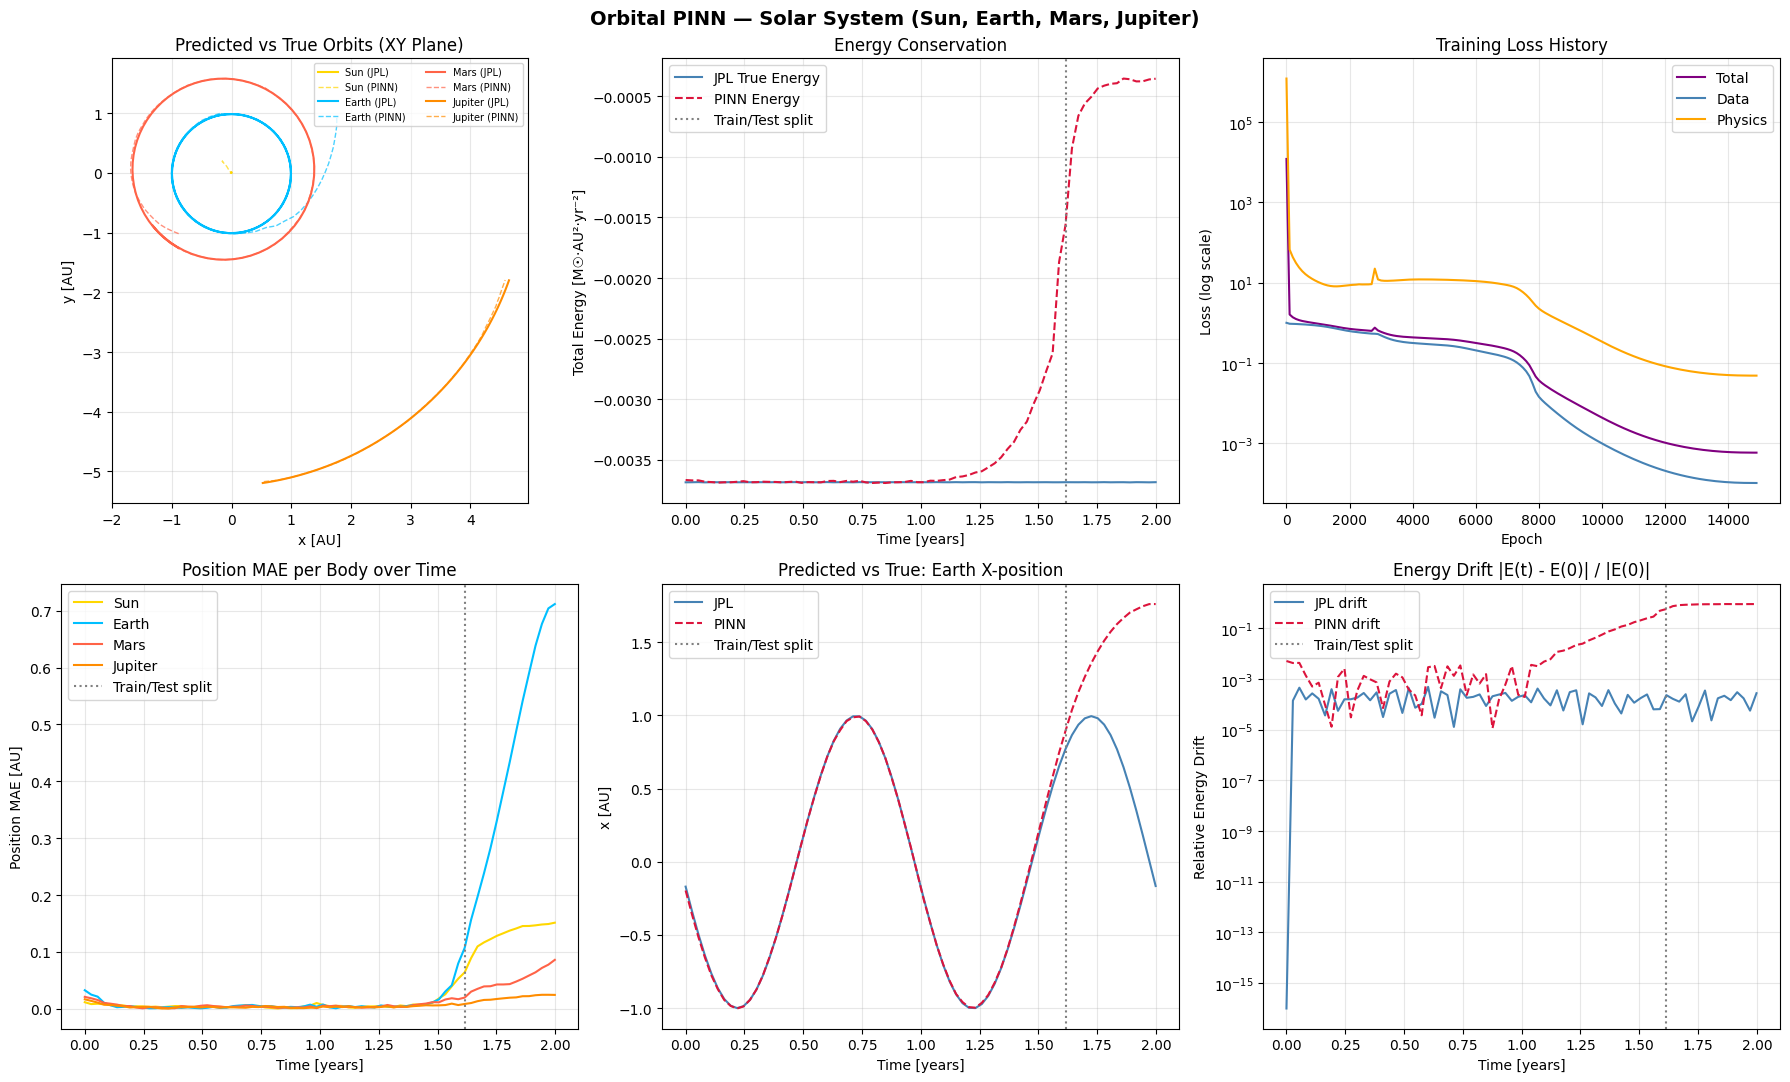


===== Final Metrics =====
Sun      | Train MAE: 0.006722 AU | Test MAE: 0.128571 AU
Earth    | Train MAE: 0.007703 AU | Test MAE: 0.431951 AU
Mars     | Train MAE: 0.005673 AU | Test MAE: 0.050109 AU
Jupiter  | Train MAE: 0.004035 AU | Test MAE: 0.018689 AU

Mean Energy Drift (PINN): 0.201835


In [ ]:


def compute_energy(states_phys, masses_np):
    E = np.zeros(len(states_phys))
    for t in range(len(states_phys)):
        KE = 0.5 * sum(masses_np[i] * np.sum(states_phys[t, i, 3:] ** 2)
                       for i in range(N_BODIES))
        PE = 0.0
        for i in range(N_BODIES):
            for j in range(i + 1, N_BODIES):
                r = np.linalg.norm(states_phys[t, j, :3] - states_phys[t, i, :3])
                PE -= G_AU * masses_np[i] * masses_np[j] / (r + 1e-12)
        E[t] = KE + PE
    return E

masses_np   = np.array([BODIES[b]["mass"] for b in BODY_NAMES])
E_true      = compute_energy(true_all, masses_np)
E_pred      = compute_energy(pred_all, masses_np)

epochs_axis = np.arange(0, EPOCHS, 100)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Orbital PINN — Solar System (Sun, Earth, Mars, Jupiter)", fontsize=14, fontweight="bold")

COLORS = ["gold", "deepskyblue", "tomato", "darkorange"]

ax = axes[0, 0]
ax.set_title("Predicted vs True Orbits (XY Plane)")
for i, name in enumerate(BODY_NAMES):
    ax.plot(true_all[:, i, 0], true_all[:, i, 1],
            color=COLORS[i], linewidth=1.5, label=f"{name} (JPL)")
    ax.plot(pred_all[:, i, 0], pred_all[:, i, 1],
            color=COLORS[i], linewidth=1, linestyle="--", alpha=0.7, label=f"{name} (PINN)")
ax.set_xlabel("x [AU]")
ax.set_ylabel("y [AU]")
ax.legend(fontsize=7, ncol=2)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.set_title("Energy Conservation")
ax.plot(t_years, E_true, label="JPL True Energy", color="steelblue")
ax.plot(t_years, E_pred, label="PINN Energy", color="crimson", linestyle="--")
ax.axvline(t_years[N_SPLIT], color="gray", linestyle=":", label="Train/Test split")
ax.set_xlabel("Time [years]")
ax.set_ylabel("Total Energy [M☉·AU²·yr⁻²]")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.set_title("Training Loss History")
ax.semilogy(epochs_axis, loss_history["total"],  label="Total",   color="purple")
ax.semilogy(epochs_axis, loss_history["data"],   label="Data",    color="steelblue")
ax.semilogy(epochs_axis, loss_history["physics"],label="Physics", color="orange")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (log scale)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.set_title("Position MAE per Body over Time")
mae = np.abs(pred_all[:, :, :3] - true_all[:, :, :3]).mean(axis=2)
for i, name in enumerate(BODY_NAMES):
    ax.plot(t_years, mae[:, i], color=COLORS[i], label=name)
ax.axvline(t_years[N_SPLIT], color="gray", linestyle=":", label="Train/Test split")
ax.set_xlabel("Time [years]")
ax.set_ylabel("Position MAE [AU]")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.set_title("Predicted vs True: Earth X-position")
ax.plot(t_years, true_all[:, 1, 0], label="JPL", color="steelblue")
ax.plot(t_years, pred_all[:, 1, 0], label="PINN", color="crimson", linestyle="--")
ax.axvline(t_years[N_SPLIT], color="gray", linestyle=":", label="Train/Test split")
ax.set_xlabel("Time [years]")
ax.set_ylabel("x [AU]")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.set_title("Energy Drift |E(t) - E(0)| / |E(0)|")
drift_true = np.abs(E_true - E_true[0]) / (np.abs(E_true[0]) + 1e-12)
drift_pred = np.abs(E_pred - E_true[0]) / (np.abs(E_true[0]) + 1e-12)
ax.semilogy(t_years, drift_true + 1e-16, label="JPL drift",  color="steelblue")
ax.semilogy(t_years, drift_pred + 1e-16, label="PINN drift", color="crimson", linestyle="--")
ax.axvline(t_years[N_SPLIT], color="gray", linestyle=":", label="Train/Test split")
ax.set_xlabel("Time [years]")
ax.set_ylabel("Relative Energy Drift")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("orbital_pinn_results.png", dpi=150, bbox_inches="tight")
plt.show()


for i, name in enumerate(BODY_NAMES):
    pos_mae_train = np.abs(pred_train[:, i, :3] - true_train[:, i, :3]).mean()
    pos_mae_test  = np.abs(pred_test[:, i, :3]  - true_test[:, i, :3]).mean()
    print(f"{name:8s} | Train MAE: {pos_mae_train * pos_std:.6f} AU | Test MAE: {pos_mae_test * pos_std:.6f} AU")

print(f"\nMean Energy Drift (PINN): {drift_pred.mean():.6f}")

In [13]:
torch.save({
    "model_state": model.state_dict(),
    "pos_std": pos_std,
    "vel_std": vel_std,
    "t_scale": t_scale,
    "t_years_min": t_years.min(),
    "t_years_max": t_years.max(),
    "body_names": BODY_NAMES,
    "masses": masses_np.tolist(),
}, "orbital_pinn_v1.pt")